In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Find the project root folder safely
PROJECT_ROOT = Path.cwd()

# If the notebook is running from inside the notebooks folder,
# move one level up to reach the main project folder.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
CMAPSS_DATA_DIR = RAW_DATA_DIR / "cmapss" / "CMAPSSData"

TRAIN_FILE_PATH = CMAPSS_DATA_DIR / "train_FD001.txt"
TEST_FILE_PATH = CMAPSS_DATA_DIR / "test_FD001.txt"
RUL_FILE_PATH = CMAPSS_DATA_DIR / "RUL_FD001.txt"

print("Project root:", PROJECT_ROOT)
print("Training file exists:", TRAIN_FILE_PATH.exists())
print("Test file exists:", TEST_FILE_PATH.exists())
print("RUL file exists:", RUL_FILE_PATH.exists())

Project root: c:\Users\VENKATESH\aircraft-rul-predictor
Training file exists: True
Test file exists: True
RUL file exists: True


In [3]:
index_columns = ['unit_number', 'time_in_cycles']

operational_setting_columns = [
    'operational_setting_1',
    'operational_setting_2',
    'operational_setting_3',
]

sensor_columns = [f'sensor_{sensor_number}' for sensor_number in range(1, 22)]

column_names = index_columns + operational_setting_columns + sensor_columns

print("Total columns", len(column_names))
print(column_names)

Total columns 26
['unit_number', 'time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [4]:
train_df = pd.read_csv(
    TRAIN_FILE_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

test_df = pd.read_csv(
    TEST_FILE_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

test_rul_df = pd.read_csv(
    RUL_FILE_PATH,
    sep=r"\s+",
    header=None,
    names=["true_rul"],
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test RUL shape:", test_rul_df.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
Test RUL shape: (100, 1)


In [5]:
train_df.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
test_df.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  sensor_11    

In [8]:
train_df.isna().sum()

unit_number              0
time_in_cycles           0
operational_setting_1    0
operational_setting_2    0
operational_setting_3    0
sensor_1                 0
sensor_2                 0
sensor_3                 0
sensor_4                 0
sensor_5                 0
sensor_6                 0
sensor_7                 0
sensor_8                 0
sensor_9                 0
sensor_10                0
sensor_11                0
sensor_12                0
sensor_13                0
sensor_14                0
sensor_15                0
sensor_16                0
sensor_17                0
sensor_18                0
sensor_19                0
sensor_20                0
sensor_21                0
dtype: int64

In [9]:
print(f'Number of training engines: {train_df['unit_number'].nunique()}')
print(f'Number of test engines: {test_df['unit_number'].nunique()}')

print("\nTraining engine IDs:")
print(train_df["unit_number"].unique()[:10])

print("\nTest engine IDs:")
print(test_df["unit_number"].unique()[:10])

Number of training engines: 100
Number of test engines: 100

Training engine IDs:
[ 1  2  3  4  5  6  7  8  9 10]

Test engine IDs:
[ 1  2  3  4  5  6  7  8  9 10]


In [10]:
# Find the final cycle for each engine in the training data
max_cycle_per_engine = train_df.groupby('unit_number')['time_in_cycles'].transform('max')

In [11]:
max_cycle_per_engine

0        192
1        192
2        192
3        192
4        192
        ... 
20626    200
20627    200
20628    200
20629    200
20630    200
Name: time_in_cycles, Length: 20631, dtype: int64

In [12]:
# RUL = final cycle of that engine - current cycle
train_df['rul'] = max_cycle_per_engine - train_df['time_in_cycles']

train_df['rul']



0        191
1        190
2        189
3        188
4        187
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: rul, Length: 20631, dtype: int64

In [13]:
train_df

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [14]:
# Cap very high RUL values at 125
MAX_RUL = 125
train_df["rul"] = train_df["rul"].clip(upper=MAX_RUL)

In [15]:
train_df

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


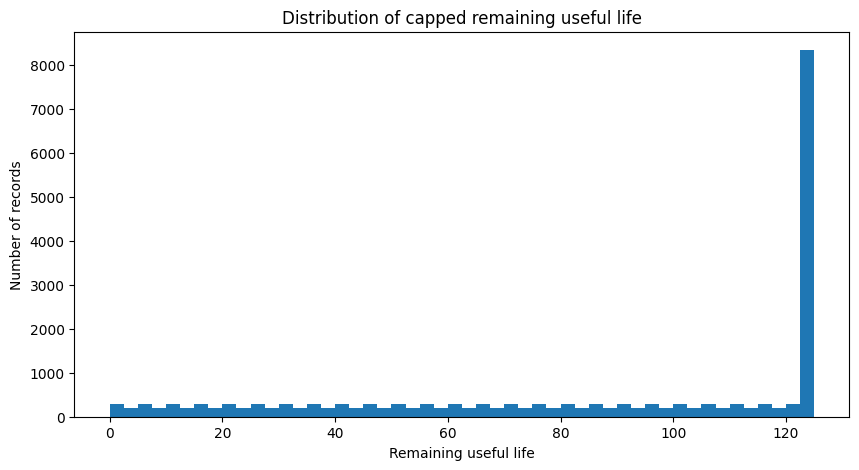

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.hist(train_df['rul'], bins = 50)
plt.title('Distribution of capped remaining useful life')
plt.xlabel('Remaining useful life')
plt.ylabel('Number of records')
plt.show()

In [17]:
engine_life = train_df.groupby('unit_number')['time_in_cycles'].max()

print("Shortest engine life:", engine_life.min())
print("Longest engine life:", engine_life.max())
print("Average engine life:", round(engine_life.mean(), 2))

engine_life.head()

Shortest engine life: 128
Longest engine life: 362
Average engine life: 206.31


unit_number
1    192
2    287
3    179
4    189
5    269
Name: time_in_cycles, dtype: int64

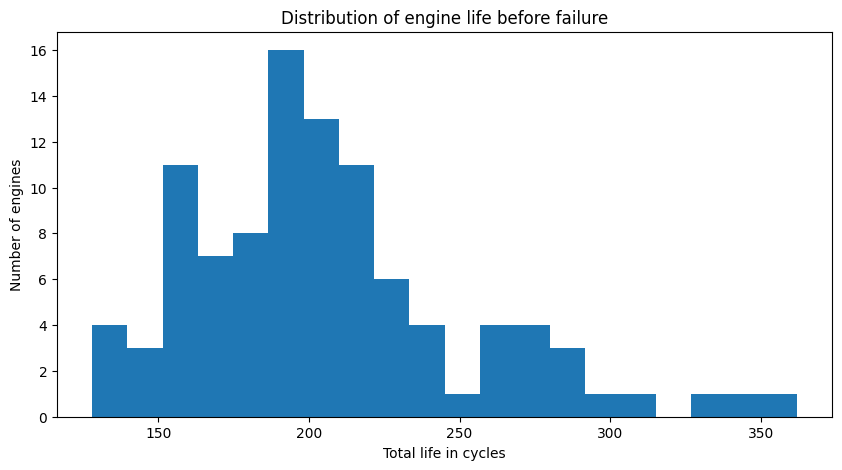

In [18]:
plt.figure(figsize = (10,5))
plt.hist(engine_life, bins = 20)
plt.title('Distribution of engine life before failure')
plt.xlabel('Total life in cycles')
plt.ylabel('Number of engines')
plt.show()

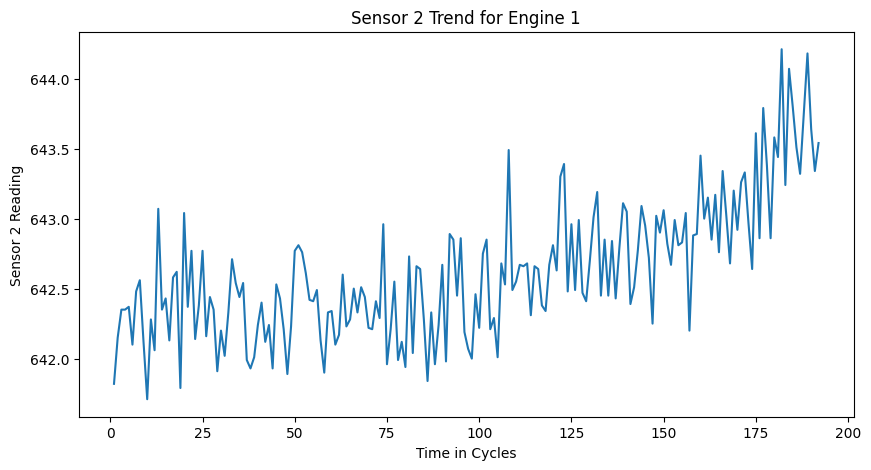

In [19]:
engine_id = 1
engine_data = train_df[train_df['unit_number'] == engine_id]
plt.figure(figsize = (10,5))
plt.plot(engine_data['time_in_cycles'], engine_data['sensor_2'])
plt.title(f"Sensor 2 Trend for Engine {engine_id}")
plt.xlabel("Time in Cycles")
plt.ylabel("Sensor 2 Reading")
plt.show()

In [20]:
# Count how many unique values each column has

unique_value_counts = train_df.nunique().sort_values()

unique_value_counts

sensor_1                    1
operational_setting_3       1
sensor_10                   1
sensor_5                    1
sensor_19                   1
sensor_16                   1
sensor_18                   1
sensor_6                    2
sensor_17                  13
operational_setting_2      13
sensor_8                   53
sensor_13                  56
unit_number               100
sensor_20                 120
rul                       126
operational_setting_1     158
sensor_11                 159
sensor_2                  310
time_in_cycles            362
sensor_12                 427
sensor_7                  513
sensor_15                1918
sensor_3                 3012
sensor_4                 4051
sensor_21                4745
sensor_14                6078
sensor_9                 6403
dtype: int64

In [21]:
constant_columns = unique_value_counts[unique_value_counts == 1].index.tolist()

columns_to_exclude = constant_columns + [
    'unit_number',
    'time_in_cycles',
    'rul',
]

feature_columns = [
    column for column in train_df.columns
    if column not in columns_to_exclude
]

print('Constant columns to remove')
print(constant_columns)

print("\nNumber of selected feature columns:", len(feature_columns))

print("\nSelected feature columns:")
print(feature_columns)

Constant columns to remove
['sensor_1', 'operational_setting_3', 'sensor_10', 'sensor_5', 'sensor_19', 'sensor_16', 'sensor_18']

Number of selected feature columns: 17

Selected feature columns:
['operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [22]:
train_df['sensor_6'].value_counts()

sensor_6
21.61    20225
21.60      406
Name: count, dtype: int64

In [23]:
y = train_df['rul']

X = train_df[feature_columns]

print('Inputs shape', X.shape)
print('Target shape', y.shape)


Inputs shape (20631, 17)
Target shape (20631,)


In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [25]:
unique_engine_ids = train_df['unit_number'].unique()

train_engine_ids, validation_engine_ids = train_test_split(
    unique_engine_ids,
    test_size=0.2,
    random_state=44
)

train_data = train_df[train_df['unit_number'].isin(train_engine_ids)]

validation_data = train_df[train_df['unit_number'].isin(validation_engine_ids)]

X_train = train_data[feature_columns]
y_train = train_data['rul']

X_validation = validation_data[feature_columns]
y_validation = validation_data['rul']

print("Training engines:", len(train_engine_ids))
print("Validation engines:", len(validation_engine_ids))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

Training engines: 80
Validation engines: 20
X_train shape: (16377, 17)
y_train shape: (16377,)
X_validation shape: (4254, 17)
y_validation shape: (4254,)


In [26]:

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_validation)

baseline_mae = mean_absolute_error(y_validation, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_validation, baseline_predictions))
baseline_r2 = r2_score(y_validation, baseline_predictions)

print("Baseline Model Performance")
print("--------------------------")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R2 Score:", round(baseline_r2, 4))

Baseline Model Performance
--------------------------
MAE: 37.06
RMSE: 41.58
R2 Score: -0.0012


In [27]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=44,
    n_jobs=-1,
)


random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_validation)
rf_mae = mean_absolute_error(y_validation, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_validation, rf_predictions))
rf_r2 = r2_score(y_validation, rf_predictions)



print("Random Forest Model Performance")
print("-------------------------------")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 4))

Random Forest Model Performance
-------------------------------
MAE: 14.67
RMSE: 19.28
R2 Score: 0.7847


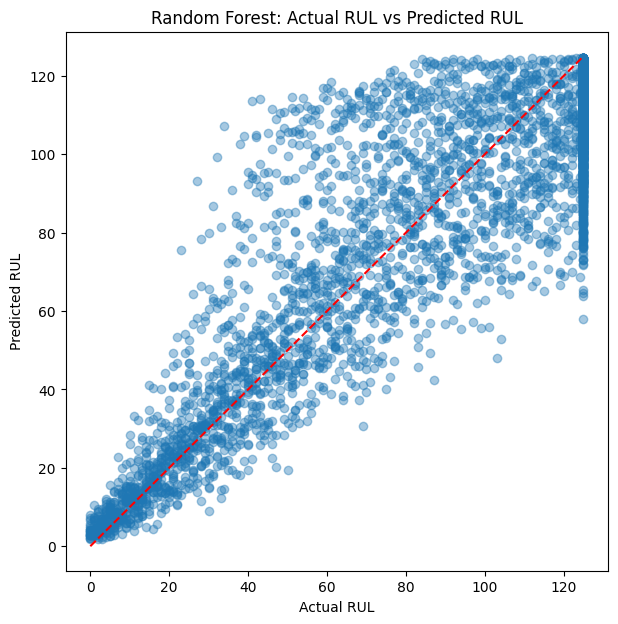

In [28]:
plt.figure(figsize = (7,7))
plt.scatter(y_validation, rf_predictions, alpha = 0.4)

plt.plot(
    [y_validation.min(), y_validation.max()],
    [y_validation.min(), y_validation.max()],
    linestyle = '--',
    color = 'red'
)

plt.title("Random Forest: Actual RUL vs Predicted RUL")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.show()

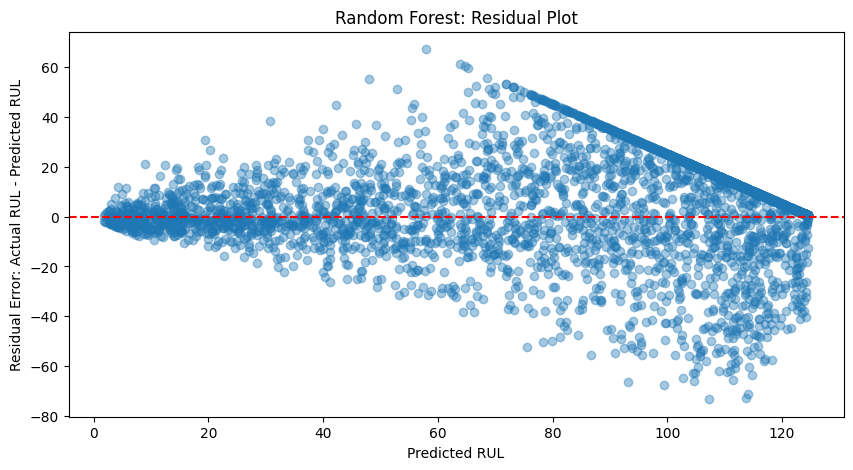

In [29]:
residuals = y_validation - rf_predictions

plt.figure(figsize = (10,5))

plt.scatter(rf_predictions, residuals, alpha = 0.4)
plt.axhline(
    y=0,
    linestyle = '--',
    color = 'red'
)

plt.title("Random Forest: Residual Plot")
plt.xlabel("Predicted RUL")
plt.ylabel("Residual Error: Actual RUL - Predicted RUL")
plt.show()

In [30]:
feature_importance = pd.DataFrame(
    {
        'feature': feature_columns,
        'importance': random_forest_model.feature_importances_,
    }
).sort_values(by = 'importance', ascending = False)

feature_importance

,feature,importance
9,sensor_11,6.130954e-01
8,sensor_9,1.313368e-01
4,sensor_4,8.988792e-02
10,sensor_12,4.490528e-02
6,sensor_7,2.148037e-02
12,sensor_14,1.979958e-02
13,sensor_15,1.606471e-02
16,sensor_21,1.091156e-02
2,sensor_2,1.010654e-02
3,sensor_3,8.945771e-03


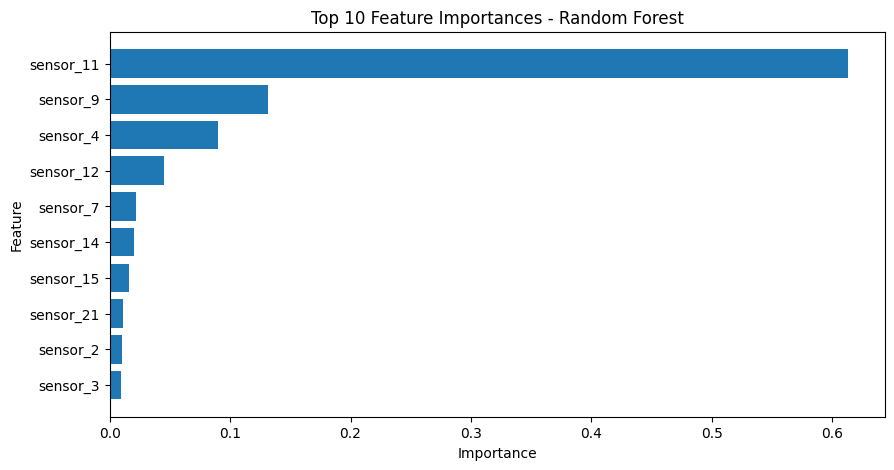

In [31]:
top_features = feature_importance.head(10)

plt.figure(figsize = (10,5))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

linear_model = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)


linear_predictions = linear_model.predict(X_validation)

linear_mae = mean_absolute_error(y_validation, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_validation, linear_predictions))
linear_r2 = r2_score(y_validation, linear_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2 Score:", round(linear_r2, 4))

Linear Regression Performance
-----------------------------
MAE: 19.42
RMSE: 23.36
R2 Score: 0.6841


In [33]:
from sklearn.linear_model import Ridge 

ridge_model = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha = 0.1)),
    ]
)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_validation)

ridge_mae = mean_absolute_error(y_validation, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_validation, ridge_predictions))
ridge_r2 = r2_score(y_validation, ridge_predictions)

print("Ridge Regression Performance")
print("----------------------------")
print("MAE:", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))
print("R2 Score:", round(ridge_r2, 4))

Ridge Regression Performance
----------------------------
MAE: 19.42
RMSE: 23.36
R2 Score: 0.6841


In [34]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha = 0.01, max_iter = 10000, random_state = 44))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_validation)
lasso_mae = mean_absolute_error(y_validation, lasso_predictions)
lasso_rmse = np.sqrt(mean_squared_error(y_validation, lasso_predictions))
lasso_r2 = r2_score(y_validation, lasso_predictions)

print("Lasso Regression Performance")
print("----------------------------")
print("MAE:", round(lasso_mae, 2))
print("RMSE:", round(lasso_rmse, 2))
print("R2 Score:", round(lasso_r2, 4))

Lasso Regression Performance
----------------------------
MAE: 19.42
RMSE: 23.36
R2 Score: 0.6841


In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter = 300,
    learning_rate = 0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=44,
)

hgb_model.fit(X_train, y_train)
hgb_predictions = hgb_model.predict(X_validation)
hgb_mae = mean_absolute_error(y_validation, hgb_predictions)
hgb_rmse = np.sqrt(mean_squared_error(y_validation, hgb_predictions))
hgb_r2 = r2_score(y_validation, hgb_predictions)

print("HistGradientBoosting Performance")
print("--------------------------------")
print("MAE:", round(hgb_mae, 2))
print("RMSE:", round(hgb_rmse, 2))
print("R2 Score:", round(hgb_r2, 4))

HistGradientBoosting Performance
--------------------------------
MAE: 14.67
RMSE: 19.36
R2 Score: 0.7829


In [36]:
from xgboost import XGBRegressor

In [37]:
from xgboost import XGBRegressor

xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgboost_model.fit(X_train, y_train)

xgb_predictions = xgboost_model.predict(X_validation)

xgb_mae = mean_absolute_error(y_validation, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_validation, xgb_predictions))
xgb_r2 = r2_score(y_validation, xgb_predictions)

print("XGBoost Performance")
print("-------------------")
print("MAE:", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R2 Score:", round(xgb_r2, 4))


XGBoost Performance
-------------------
MAE: 14.55
RMSE: 19.24
R2 Score: 0.7856


In [38]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline Mean",
            "mae": baseline_mae,
            "rmse": baseline_rmse,
            "r2_score": baseline_r2,
        },
        {
            "model": "Linear Regression",
            "mae": linear_mae,
            "rmse": linear_rmse,
            "r2_score": linear_r2,
        },
        {
            "model": "Ridge Regression",
            "mae": ridge_mae,
            "rmse": ridge_rmse,
            "r2_score": ridge_r2,
        },
        {
            "model": "Lasso Regression",
            "mae": lasso_mae,
            "rmse": lasso_rmse,
            "r2_score": lasso_r2,
        },
        {
            "model": "Random Forest",
            "mae": rf_mae,
            "rmse": rf_rmse,
            "r2_score": rf_r2,
        },
        {
            "model": "HistGradientBoosting",
            "mae": hgb_mae,
            "rmse": hgb_rmse,
            "r2_score": hgb_r2,
        },
        {
            "model": "XGBoost",
            "mae": xgb_mae,
            "rmse": xgb_rmse,
            "r2_score": xgb_r2,
        },
    ]
)

model_comparison = model_comparison.sort_values(by="mae")

model_comparison

,model,mae,rmse,r2_score
6,XGBoost,14.547404,19.243505,0.785562
5,HistGradientBoosting,14.666198,19.364483,0.782857
4,Random Forest,14.671336,19.284032,0.784658
1,Linear Regression,19.423365,23.356480,0.684101
2,Ridge Regression,19.423366,23.356479,0.684101
3,Lasso Regression,19.423617,23.356563,0.684099
0,Baseline Mean,37.055638,41.581063,-0.001208


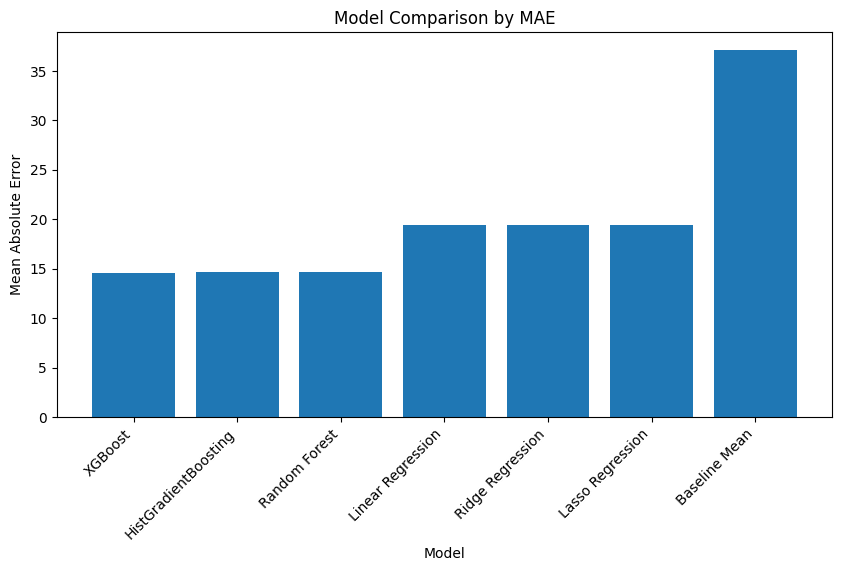

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["mae"],
)

plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45, ha="right")
plt.show()

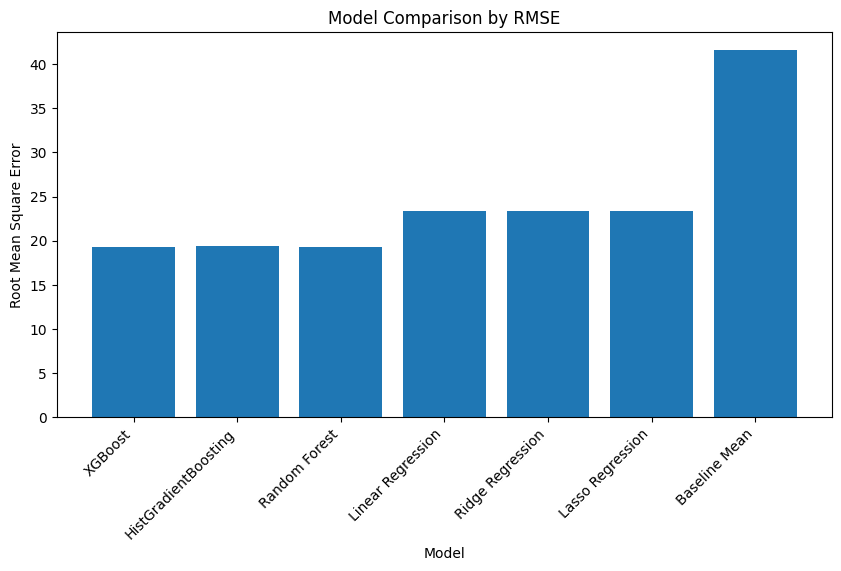

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["rmse"],
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Square Error")
plt.xticks(rotation=45, ha="right")
plt.show()

In [43]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1, 3, 5],
}

group_cv = GroupKFold(n_splits=3)

xgb_base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base_model,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(
    X_train,
    y_train,
    groups=train_data["unit_number"],
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest GroupKFold CV MAE:")
print(round(-xgb_search.best_score_, 2))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Best GroupKFold CV MAE:
13.32


In [44]:
best_xgb_model = xgb_search.best_estimator_

tuned_xgb_predictions = best_xgb_model.predict(X_validation)

tuned_xgb_mae = mean_absolute_error(y_validation, tuned_xgb_predictions)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_validation, tuned_xgb_predictions))
tuned_xgb_r2 = r2_score(y_validation, tuned_xgb_predictions)

print("Tuned XGBoost Validation Performance")
print("------------------------------------")
print("MAE:", round(tuned_xgb_mae, 2))
print("RMSE:", round(tuned_xgb_rmse, 2))
print("R2 Score:", round(tuned_xgb_r2, 4))

Tuned XGBoost Validation Performance
------------------------------------
MAE: 14.51
RMSE: 19.18
R2 Score: 0.7869


In [45]:
tuned_xgb_result = pd.DataFrame(
    [
        {
            "model": "Tuned XGBoost",
            "mae": tuned_xgb_mae,
            "rmse": tuned_xgb_rmse,
            "r2_score": tuned_xgb_r2,
        }
    ]
)

final_model_comparison = pd.concat(
    [model_comparison, tuned_xgb_result],
    ignore_index=True,
)

final_model_comparison = final_model_comparison.sort_values(by="mae")

final_model_comparison

,model,mae,rmse,r2_score
7,Tuned XGBoost,14.512342,19.181266,0.786947
0,XGBoost,14.547404,19.243505,0.785562
1,HistGradientBoosting,14.666198,19.364483,0.782857
2,Random Forest,14.671336,19.284032,0.784658
3,Linear Regression,19.423365,23.356480,0.684101
4,Ridge Regression,19.423366,23.356479,0.684101
5,Lasso Regression,19.423617,23.356563,0.684099
6,Baseline Mean,37.055638,41.581063,-0.001208


In [46]:
import joblib

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

FINAL_MODEL_PATH = MODELS_DIR / 'xgboost_rul_model.joblib'

model_artifact = {
    'model': best_xgb_model,
    'feature_columns': feature_columns,
    'max_rul': MAX_RUL,
    'model_name': 'Tuned XGBoost',
    'validation_mae': tuned_xgb_mae, 
    'validation_rmse': tuned_xgb_rmse,
    'validation_r2': tuned_xgb_r2,
}


joblib.dump(model_artifact, FINAL_MODEL_PATH)

print('Final model saved successfully at:')
print(FINAL_MODEL_PATH)

Final model saved successfully at:
c:\Users\VENKATESH\aircraft-rul-predictor\models\xgboost_rul_model.joblib
